# Chapter 22 — The Cosmic Microwave Background

!!! info "Before you start"
    **Prerequisites:** Ch 2 (The Physics of Radio Emission) · **Maths Lab:** [Lab A (Fourier & Convolution)](31_mathslab_fourier_convolution.ipynb) · **~45 min** · **Intermediate**

In [Chapter 2](02_physics_of_radio_emission.ipynb) we learned why radio astronomers
measure *temperatures*: across the whole radio band the Planck law collapses to the
classical **Rayleigh–Jeans law**, $B_\nu = 2 k_B T \nu^2 / c^2$, so brightness *is* a
temperature. We met `jansky.units.planck_brightness`, `rayleigh_jeans_brightness`, and
the brightness-temperature machinery. This chapter cashes that in on the single most
famous measurement in the history of radio astronomy.

In 1965 two Bell Labs engineers, **Arno Penzias and Robert Wilson**, were trying to
calibrate a sensitive horn antenna at $4080\,\mathrm{MHz}$ and could not get rid of a
faint, uniform hiss — an *excess antenna temperature* of about $3.5\,\mathrm{K}$ that
came from every direction and would not go away. It was the relic heat of the Big Bang:
the **cosmic microwave background (CMB)**. They won the 1978 Nobel Prize for it. The CMB
is a near-perfect $2.725\,\mathrm{K}$ blackbody, and — because that blackbody peaks in
the *microwave* — radio observations of it sit squarely on the Rayleigh–Jeans tail we
studied in Chapter 2.

## Learning goals

By the end of this chapter you will be able to:

- **Tell the discovery story** as a piece of radio astronomy: Penzias & Wilson's excess
  antenna temperature, and Dicke's group predicting exactly such a relic at the same time.
- **Plot the CMB as a $2.725\,\mathrm{K}$ blackbody** with `jansky.units.planck_brightness`,
  locate its $\sim 160\,\mathrm{GHz}$ peak, and show with `rayleigh_jeans_brightness` that
  radio measurements live on the RJ tail (and where RJ finally breaks down).
- **Model the kinematic dipole** $\Delta T/T = (v/c)\cos\theta$ from the Sun's
  $\sim 370\,\mathrm{km\,s^{-1}}$ motion, and recover the $\sim 3.36\,\mathrm{mK}$ amplitude.
- **Build a toy angular power spectrum**: a flat-sky Gaussian-random temperature map with a
  chosen 2-D power spectrum, and its radially-averaged power spectrum — a *concept demo* for
  the real $C_\ell$ with its acoustic peaks.

Everything runs on the base `jansky` environment: numpy / scipy / astropy + `jansky`, with
**no network and no optional extras** (in particular, no `healpy` — we work on a flat sky).

## 1 · Orientation — the discovery as radio astronomy

The CMB was found the way Jansky found the Galaxy: as **noise that would not go away**.

> **Penzias, A. A. & Wilson, R. W.** (1965), *A Measurement of Excess Antenna Temperature
> at 4080 Mc/s*, ApJ **142**, 419.
> [ADS](https://ui.adsabs.harvard.edu/abs/1965ApJ...142..419P)

Penzias and Wilson were characterising the Holmdel horn antenna — a beautifully clean
$20$-foot horn reflector built for early satellite communications. After accounting for
the atmosphere, the ground, and the receiver, they were left with an **excess antenna
temperature** of about $3.5 \pm 1\,\mathrm{K}$ at $4080\,\mathrm{MHz}$ ($\lambda = 7.35$ cm).
It was *isotropic* (the same in every direction), *unpolarised*, and *constant in time* —
not the Galaxy, not the Sun, not a discrete source, and (famously) not the pigeons nesting
in the horn, whose droppings they cleaned out to no effect. Their paper is a model of
careful radio calibration: it is barely a page long and never claims a cosmological origin.

The interpretation came from a companion paper in the *same* journal issue:

> **Dicke, R. H., Peebles, P. J. E., Roll, P. G. & Wilkinson, D. T.** (1965),
> *Cosmic Black-Body Radiation*, ApJ **142**, 414.
> [ADS](https://ui.adsabs.harvard.edu/abs/1965ApJ...142..414D)

Dicke's Princeton group had *predicted* a relic thermal radiation field from a hot early
universe and were building their own radiometer to look for it when they heard about
Holmdel. As Dicke reportedly put it to his team: *"Boys, we've been scooped."* The two
papers ran back-to-back: Penzias & Wilson reporting the measurement, Dicke et al. supplying
the cosmology. (Earlier, Gamow, Alpher and Herman had predicted a few-kelvin background in
the late 1940s, but the prediction had been largely forgotten.)

The story is pure radio astronomy: a horn antenna, an antenna temperature, and the
relentless hunt for the source of an excess noise floor — exactly the system temperature
budget of [Chapter 3](03_signals_noise_radiometer.ipynb). What turned a $3.5\,\mathrm{K}$
nuisance into a Nobel Prize was realising it was the same in every direction because it
fills the whole sky.

## 2 · A 2.725 K blackbody

What Penzias and Wilson measured at one frequency, later experiments mapped out across the
whole spectrum — and the CMB turned out to be the most perfect blackbody ever measured. The
NASA **COBE/FIRAS** instrument nailed it:

> **Mather, J. C. et al.** (1994), *Measurement of the CMB Spectrum by the COBE FIRAS
> Instrument*, ApJ **420**, 439.
> [ADS](https://ui.adsabs.harvard.edu/abs/1994ApJ...420..439M)

FIRAS found a Planck spectrum at $T_0 = 2.725 \pm 0.002\,\mathrm{K}$ with deviations smaller
than $50$ parts per million — a blackbody so precise that the error bars are thinner than
the printed curve. (George Smoot and John Mather shared the 2006 Nobel Prize for the COBE
results: Mather for this spectrum, Smoot for the anisotropy we reach in §4.)

The Planck law (Chapter 2) is

$$
B_\nu(T) \;=\; \frac{2 h \nu^3}{c^2}\,\frac{1}{e^{h\nu / k_B T} - 1}
\qquad \left[\mathrm{W\,m^{-2}\,Hz^{-1}\,sr^{-1}}\right],
$$

and its peak (in $B_\nu$) sits at $h\nu_\mathrm{peak} \approx 2.821\,k_B T$, i.e.

$$
\nu_\mathrm{peak} \;\approx\; 2.821\,\frac{k_B T}{h} \;\approx\; 160\,\mathrm{GHz}
\quad\text{for } T = 2.725\,\mathrm{K}.
$$

That is in the microwave — hence the *M* in CMB — and it is *above* the radio band. So a
radio telescope observing the CMB at, say, $4\,\mathrm{GHz}$ (Penzias & Wilson) or
$1.4\,\mathrm{GHz}$ (the HI line, Chapter 6) sits far out on the low-frequency
**Rayleigh–Jeans tail**, where $B_\nu \propto \nu^2 T$ and the brightness temperature is
flat. Let's draw exactly that.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
import astropy.constants as const

from jansky import units, signals, plotting

plotting.use_jansky_style()

# Every random draw in this chapter goes through one seeded generator.
rng = signals.rng(seed=2725)
print("jansky CMB chapter ready — using helpers:",
      "units.planck_brightness, units.rayleigh_jeans_brightness,",
      "units.flux_to_brightness_temperature, units.to_decibels")

jansky CMB chapter ready — using helpers: units.planck_brightness, units.rayleigh_jeans_brightness, units.flux_to_brightness_temperature, units.to_decibels


In [2]:
# The CMB temperature (COBE/FIRAS, Mather et al. 1994 / Fixsen 2009).
T_cmb = 2.725 * u.K

# Frequency grid from 1 GHz up through the peak into the Wien tail.
freq = np.logspace(np.log10(1e9), np.log10(1.5e12), 800) * u.Hz   # 1 GHz -> 1.5 THz

# Full Planck curve and the Rayleigh-Jeans approximation, both from jansky.units.
B_planck = units.planck_brightness(T_cmb, freq)          # exact blackbody
B_rj = units.rayleigh_jeans_brightness(T_cmb, freq)      # 2 k_B T nu^2 / c^2

# Peak of the Planck B_nu curve: numerically, and from the Wien-like relation.
i_peak = int(np.argmax(B_planck.value))
nu_peak_numeric = freq[i_peak].to(u.GHz)
nu_peak_wien = (2.8214393721 * const.k_B * T_cmb / const.h).to(u.GHz)

print(f"CMB temperature:        T_0 = {T_cmb}")
print(f"Planck B_nu peak (grid):      {nu_peak_numeric:.1f}")
print(f"Planck B_nu peak (2.821 kT/h): {nu_peak_wien:.1f}")

# Where does the RJ approximation break down? Find the 1% and 10% error frequencies.
frac_err = np.abs(B_rj - B_planck) / B_planck
nu_1pct = freq[np.argmax(frac_err.value > 0.01)].to(u.GHz)
nu_10pct = freq[np.argmax(frac_err.value > 0.10)].to(u.GHz)
print(f"\nRayleigh-Jeans is accurate to <1%  below {nu_1pct:.2f}")
print(f"Rayleigh-Jeans is off by   >10% above {nu_10pct:.2f}")

CMB temperature:        T_0 = 2.725 K
Planck B_nu peak (grid):      160.8 GHz
Planck B_nu peak (2.821 kT/h): 160.2 GHz

Rayleigh-Jeans is accurate to <1%  below 1.14 GHz
Rayleigh-Jeans is off by   >10% above 10.70 GHz


### Figure 1 — the CMB blackbody and its Rayleigh–Jeans tail

Left: the full Planck curve for $T = 2.725\,\mathrm{K}$ on log–log axes, with the
Rayleigh–Jeans approximation overplotted. They are indistinguishable across the radio band
(shaded) and only part company as we climb toward the $\sim 160\,\mathrm{GHz}$ peak; beyond
the peak the true spectrum turns over (the Wien tail) while RJ keeps rising as $\nu^2$.
Right: the same curves on linear axes, where the blackbody hump and its peak are obvious,
with the radio observing frequencies of Penzias & Wilson ($4.08\,\mathrm{GHz}$) and the HI
line ($1.42\,\mathrm{GHz}$) marked far down on the rising tail.

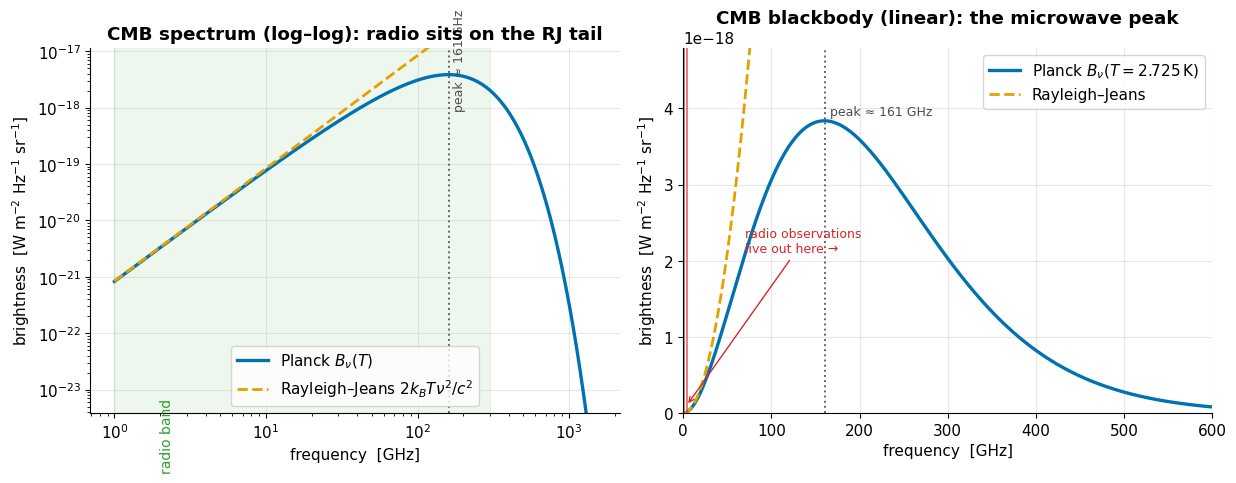

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5.0))

# --- Left: log-log, Planck vs Rayleigh-Jeans ---
ax1.loglog(freq.to(u.GHz), B_planck.value, lw=2.4, label=r"Planck $B_\nu(T)$")
ax1.loglog(freq.to(u.GHz), B_rj.value, lw=2.0, ls="--",
           label=r"Rayleigh–Jeans $2k_BT\nu^2/c^2$")
ax1.axvspan(1, 300, color="tab:green", alpha=0.08)         # radio band
ax1.text(2, B_planck.value.min() * 2, "radio band", color="tab:green",
         fontsize=10, rotation=90, va="bottom")
ax1.axvline(nu_peak_numeric.value, color="0.4", ls=":", lw=1.4)
ax1.text(nu_peak_numeric.value * 1.06, B_planck.value.max() * 0.25,
         f"peak ≈ {nu_peak_numeric.value:.0f} GHz", rotation=90, fontsize=9, color="0.3")
ax1.set_xlabel("frequency  [GHz]")
ax1.set_ylabel(r"brightness  [W m$^{-2}$ Hz$^{-1}$ sr$^{-1}$]")
ax1.set_title("CMB spectrum (log–log): radio sits on the RJ tail")
ax1.set_ylim(B_planck.value.max() * 1e-6, B_planck.value.max() * 3)
ax1.legend(loc="lower center")

# --- Right: linear axes show the blackbody hump and its peak ---
freq_ghz = freq.to(u.GHz).value
ax2.plot(freq_ghz, B_planck.value, lw=2.4, label=r"Planck $B_\nu(T=2.725\,$K$)$")
ax2.plot(freq_ghz, B_rj.value, lw=2.0, ls="--", label="Rayleigh–Jeans")
ax2.axvline(nu_peak_numeric.value, color="0.4", ls=":", lw=1.4)
ax2.set_ylim(0, B_planck.value.max() * 1.25)
ax2.set_xlim(0, 600)
# Mark the radio observing frequencies, far down the rising tail.
for nu_mark, name in [(4.08, "Penzias & Wilson\n4.08 GHz"), (1.42, "HI line\n1.42 GHz")]:
    ax2.axvline(nu_mark, color="tab:red", lw=1.2, alpha=0.7)
ax2.annotate("radio observations\nlive out here →", xy=(4, 1e-19),
             xytext=(70, B_planck.value.max() * 0.55), fontsize=9, color="tab:red",
             arrowprops=dict(arrowstyle="->", color="tab:red"))
ax2.text(nu_peak_numeric.value + 6, B_planck.value.max() * 1.02,
         f"peak ≈ {nu_peak_numeric.value:.0f} GHz", fontsize=9, color="0.3")
ax2.set_xlabel("frequency  [GHz]")
ax2.set_ylabel(r"brightness  [W m$^{-2}$ Hz$^{-1}$ sr$^{-1}$]")
ax2.set_title("CMB blackbody (linear): the microwave peak")
ax2.legend(loc="upper right")

fig.tight_layout()
plt.show()

### Brightness temperature is flat on the radio tail

Chapter 2 *defined* the brightness temperature as the temperature a Rayleigh–Jeans blackbody
would need to produce the observed brightness. For a genuine blackbody in the RJ regime that
recovered temperature must just be $T$ itself — independent of frequency. Let's confirm it by
running the CMB's own brightness back through `units.flux_to_brightness_temperature` at a
handful of radio frequencies. (We integrate $B_\nu$ over a $1\,\mathrm{arcmin}^2$ patch to get
a flux, then invert; the solid angle cancels, so the recovered $T_b$ is what matters.)

In [4]:
omega = (1.0 * u.arcmin**2).to(u.sr)        # any patch; the solid angle cancels out
radio_freqs = [0.408, 1.42, 4.08, 30.0, 90.0] * u.GHz

print(f"{'nu [GHz]':>10} {'T_b (RJ) [K]':>16} {'h*nu/k_B*T':>14}")
print("-" * 42)
for nu in radio_freqs:
    # True CMB brightness from the exact Planck law -> flux over the patch.
    B = units.planck_brightness(T_cmb, nu)
    S = (B * omega).to(u.Jy)
    # Invert with the Rayleigh-Jeans relation (the radio definition of T_b).
    T_b = units.flux_to_brightness_temperature(S, nu, omega)
    x = (const.h * nu / (const.k_B * T_cmb)).to_value(u.dimensionless_unscaled)
    print(f"{nu.value:>10.3f} {T_b.value:>16.4f} {x:>14.4f}")

print(f"\nThermodynamic temperature: {T_cmb.value:.3f} K")
print("In the radio (small h*nu/k_B*T) the RJ brightness temperature equals T_0;")
print("it only starts to droop as h*nu approaches k_B*T near the peak (x -> 1).")

  nu [GHz]     T_b (RJ) [K]     h*nu/k_B*T
------------------------------------------
     0.408           2.7152         0.0072
     1.420           2.6911         0.0250
     4.080           2.6283         0.0719
    30.000           2.0682         0.5284
    90.000           1.1133         1.5851

Thermodynamic temperature: 2.725 K
In the radio (small h*nu/k_B*T) the RJ brightness temperature equals T_0;
it only starts to droop as h*nu approaches k_B*T near the peak (x -> 1).


So at $0.4$–$4\,\mathrm{GHz}$ the CMB's Rayleigh–Jeans brightness temperature is the
$2.725\,\mathrm{K}$ thermodynamic temperature to four decimal places — exactly why Penzias &
Wilson could quote their result as a single *antenna temperature*. The small droop you see by
$90\,\mathrm{GHz}$ is the same $h\nu \to k_B T$ correction that bent the Planck curve away from
RJ in Figure 1. This is the Chapter-2 story playing out on the most important blackbody in the
sky.

## 3 · The dipole — our motion through the radiation

The CMB is isotropic to about one part in $10^5$ — but not perfectly. The largest anisotropy,
$\sim 10^3$ times bigger than all the rest, is a smooth **dipole**: one side of the sky is
slightly hotter and the opposite side slightly cooler. This is not cosmology; it is the Doppler
shift of our own motion. The Solar System moves through the CMB rest frame at
$v \approx 370\,\mathrm{km\,s^{-1}}$ (toward the constellation Leo), so the radiation is
blueshifted ahead of us and redshifted behind.

To first order in $\beta = v/c$ the observed temperature in a direction making angle $\theta$
with our motion is

$$
T(\theta) \;=\; \frac{T_0}{\gamma\,(1 - \beta\cos\theta)}
\;\approx\; T_0\left(1 + \beta\cos\theta\right),
\qquad\text{so}\qquad
\boxed{\;\frac{\Delta T}{T_0} \;\approx\; \frac{v}{c}\,\cos\theta\;}
$$

a pure $\cos\theta$ pattern. The amplitude is

$$
\Delta T_\mathrm{dipole} \;=\; T_0\,\frac{v}{c}
\;\approx\; 2.725\,\mathrm{K}\times\frac{370}{3\times10^{5}}
\;\approx\; 3.4\,\mathrm{mK}.
$$

The measured value is $3.3621 \pm 0.0010\,\mathrm{mK}$ (Planck 2018), corresponding to
$v = 369.8\,\mathrm{km\,s^{-1}}$. Let's compute it and plot the dipole pattern.

In [5]:
v_sun = 369.82 * u.km / u.s         # Solar System speed wrt the CMB (Planck 2018)
beta = (v_sun / const.c).to_value(u.dimensionless_unscaled)

# Dipole amplitude Delta T = T_0 * v/c.
dT_dipole = (T_cmb * beta).to(u.mK)
print(f"beta = v/c = {beta:.3e}")
print(f"Dipole amplitude  Delta T = T_0 * v/c = {dT_dipole:.4f}")
print(f"  (measured: 3.3621 +/- 0.0010 mK, Planck 2018)")

# Temperature vs angle from the apex of motion (exact and first-order forms).
theta = np.linspace(0, np.pi, 400)                      # radians, 0 = direction of motion
gamma = 1.0 / np.sqrt(1.0 - beta**2)
T_exact = T_cmb.value / (gamma * (1.0 - beta * np.cos(theta)))   # full relativistic
T_firstorder = T_cmb.value * (1.0 + beta * np.cos(theta))        # dipole approximation
dT_uK = (T_exact - T_cmb.value) * 1e6                            # anisotropy in microkelvin

beta = v/c = 1.234e-03
Dipole amplitude  Delta T = T_0 * v/c = 3.3615 mK
  (measured: 3.3621 +/- 0.0010 mK, Planck 2018)


### Figure 2 — the kinematic dipole

Left: the fractional temperature change $\Delta T/T_0$ as a function of angle $\theta$ from
the apex of our motion — a clean $\cos\theta$ curve, hottest dead ahead ($\theta = 0$) and
coldest directly behind ($\theta = \pi$). Right: a sky map of the dipole. Because $\Delta T/T$
is only $\sim 10^{-3}$ the exact relativistic curve and the first-order approximation lie
right on top of each other; the residual between them (a tiny quadrupole-like term) is the
next order in $\beta$.

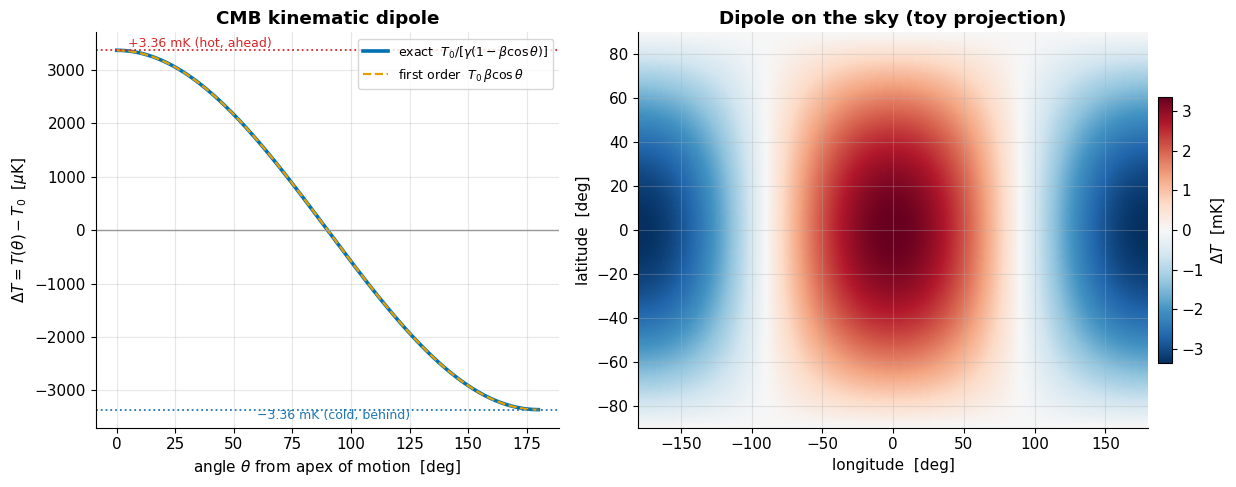

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5.0),
                               gridspec_kw={"width_ratios": [1, 1.15]})

# --- Left: Delta T vs angle ---
ax1.plot(np.degrees(theta), dT_uK, lw=2.6, label="exact  $T_0/[\\gamma(1-\\beta\\cos\\theta)]$")
ax1.plot(np.degrees(theta), (T_firstorder - T_cmb.value) * 1e6, lw=1.6, ls="--",
         label=r"first order  $T_0\,\beta\cos\theta$")
ax1.axhline(0, color="0.6", lw=1)
ax1.axhline(dT_dipole.to(u.uK).value, color="tab:red", ls=":", lw=1.3)
ax1.axhline(-dT_dipole.to(u.uK).value, color="tab:blue", ls=":", lw=1.3)
ax1.text(5, dT_dipole.to(u.uK).value + 60, f"+{dT_dipole.to(u.mK).value:.2f} mK (hot, ahead)",
         color="tab:red", fontsize=9)
ax1.text(60, -dT_dipole.to(u.uK).value - 180, f"−{dT_dipole.to(u.mK).value:.2f} mK (cold, behind)",
         color="tab:blue", fontsize=9)
ax1.set_xlabel(r"angle $\theta$ from apex of motion  [deg]")
ax1.set_ylabel(r"$\Delta T = T(\theta) - T_0$  [$\mu$K]")
ax1.set_title("CMB kinematic dipole")
ax1.legend(loc="upper right", fontsize=9)

# --- Right: a full-sky dipole map in a simple (l, b)-like grid ---
n_lon, n_lat = 360, 180
lon = np.linspace(-np.pi, np.pi, n_lon)
lat = np.linspace(-np.pi / 2, np.pi / 2, n_lat)
LON, LAT = np.meshgrid(lon, lat)
# Place the apex of motion on the equator at lon = 0; angle to apex via the dot product.
cos_to_apex = np.cos(LAT) * np.cos(LON)
dipole_map_mK = T_cmb.value * beta * cos_to_apex * 1e3        # mK

im = ax2.imshow(dipole_map_mK, extent=[-180, 180, -90, 90], aspect="auto",
                cmap="RdBu_r", vmin=-dT_dipole.to(u.mK).value, vmax=dT_dipole.to(u.mK).value)
ax2.set_xlabel("longitude  [deg]")
ax2.set_ylabel("latitude  [deg]")
ax2.set_title("Dipole on the sky (toy projection)")
fig.colorbar(im, ax=ax2, fraction=0.025, pad=0.02, label=r"$\Delta T$  [mK]")

fig.tight_layout()
plt.show()

Subtract this dipole and the next-largest signal is a thousand times fainter: the
true primordial anisotropy, at the $\sim 10\,\mu\mathrm{K}$ level. That is where the cosmology
lives, and it is where we go next.

## 4 · Anisotropy and the angular power spectrum (a toy)

Once the dipole is removed, the CMB sky is covered in faint $\sim 10\,\mu\mathrm{K}$ ripples.
**COBE/DMR** first detected them (Smoot et al. 1992 — the other half of the 2006 Nobel), and
**WMAP** and **Planck** then mapped them in exquisite detail:

> **Smoot, G. F. et al.** (1992), *Structure in the COBE DMR First-Year Maps*, ApJ **396**, L1.
> [ADS](https://ui.adsabs.harvard.edu/abs/1992ApJ...396L...1S)
>
> **Bennett, C. L. et al.** (2003), *First-Year WMAP Observations: Preliminary Maps and Basic
> Results*, ApJS **148**, 1. [ADS](https://ui.adsabs.harvard.edu/abs/2003ApJS..148....1B)

The statistics of those ripples are summarised by the **angular power spectrum**. On the full
sphere you expand the temperature map in spherical harmonics, $\Delta T(\hat n) = \sum_{\ell m}
a_{\ell m} Y_{\ell m}(\hat n)$, and the power at each angular scale is
$C_\ell = \langle |a_{\ell m}|^2 \rangle$. A multipole $\ell$ corresponds roughly to an angular
scale $\theta \sim 180^\circ/\ell$. The real $C_\ell$ has a series of **acoustic peaks** — frozen
sound waves in the primordial plasma — whose positions and heights encode the geometry and
contents of the universe. That is the engine of modern precision cosmology.

A full $C_\ell$ analysis needs spherical harmonics on the sphere (e.g. `healpy`), which is an
optional extra we deliberately avoid here. Instead we build a **flat-sky toy**: treat a small
patch of sky as a flat plane, where spherical harmonics become an ordinary 2-D Fourier
transform, and the multipole $\ell$ becomes a 2-D spatial frequency. We will

1. *choose* a 2-D power spectrum $P(k)$ with a bump at a characteristic scale (a stand-in for
   "an acoustic peak"),
2. generate a Gaussian-random map with exactly that power spectrum using a seeded `numpy` FFT, and
3. measure its **radially-averaged power spectrum** and check we get our input shape back.

> **This is a concept demo, not data.** It is *not* a real CMB map, the bump is *not* a real
> acoustic peak, and the recovered curve is *not* a real $C_\ell$. It exists only to show how a
> map and its power spectrum relate. The real spectrum — with its true peak structure — was
> measured by WMAP and Planck.

In [7]:
# ---- Flat-sky grid -------------------------------------------------------
npix = 256                      # pixels per side
patch_deg = 20.0                # angular size of the (square) patch, degrees
res_deg = patch_deg / npix      # pixel scale
res_rad = np.radians(res_deg)

# 2-D spatial frequencies. On a flat sky the multipole is ell = 2*pi*k, where k is the
# spatial frequency in cycles per radian (numpy.fft.fftfreq gives cycles per pixel).
kx = np.fft.fftfreq(npix, d=res_rad)            # cycles per radian
ky = np.fft.fftfreq(npix, d=res_rad)
KX, KY = np.meshgrid(kx, ky)
K = np.sqrt(KX**2 + KY**2)                       # radial spatial frequency [cycles/rad]
ELL = 2.0 * np.pi * K                            # flat-sky multipole

print(f"Patch: {patch_deg:.0f} deg on a side, {npix} pixels  ->  {res_deg*60:.1f} arcmin/pixel")
print(f"Multipole range probed: ell = {ELL[ELL > 0].min():.0f} ... {ELL.max():.0f}")

Patch: 20 deg on a side, 256 pixels  ->  4.7 arcmin/pixel
Multipole range probed: ell = 18 ... 3258


In [8]:
# ---- Choose a toy power spectrum with a 'peak' --------------------------
# A broad envelope that falls at small scales, times a Gaussian bump at ell ~ ell_peak.
# This is an ad-hoc shape standing in for the real C_ell; it is NOT physical.
ell_peak = 220.0          # location of our toy 'acoustic peak' (real first peak ~ 220!)
ell_width = 90.0          # width of the bump

def toy_power_spectrum(ell):
    ell = np.asarray(ell, dtype=float)
    envelope = 1.0 / (1.0 + (ell / 600.0) ** 2)            # large-scale plateau, small-scale falloff
    bump = 1.5 * np.exp(-0.5 * ((ell - ell_peak) / ell_width) ** 2)   # the 'peak'
    return envelope + bump

P_2d = toy_power_spectrum(ELL)
P_2d[0, 0] = 0.0          # zero the DC (mean) mode

# ---- Generate a Gaussian-random map with this power spectrum -------------
# Draw white Gaussian noise in Fourier space, colour it by sqrt(P(k)), inverse-FFT to a
# real map. Hermitian symmetry of np.fft.irfft-style construction is handled by irfft2.
white = (rng.standard_normal((npix, npix)) + 1j * rng.standard_normal((npix, npix))) / np.sqrt(2)
fourier = white * np.sqrt(P_2d)
cmb_toy = np.fft.ifft2(fourier).real
# Normalise to a realistic anisotropy amplitude (~100 uK rms) purely for nice numbers.
cmb_toy *= (100e-6 / cmb_toy.std())
cmb_toy_uK = cmb_toy * 1e6
print(f"Toy map: {npix}x{npix},  rms = {cmb_toy_uK.std():.1f} uK,  "
      f"peak-to-peak = {np.ptp(cmb_toy_uK):.0f} uK")

Toy map: 256x256,  rms = 100.0 uK,  peak-to-peak = 794 uK


In [9]:
# ---- Radially average the map's own 2-D power spectrum -------------------
power_2d = np.abs(np.fft.fft2(cmb_toy)) ** 2

# Bin in ell.
ell_flat = ELL.ravel()
power_flat = power_2d.ravel()
ell_bins = np.linspace(0, 1500, 40)
which = np.digitize(ell_flat, ell_bins)
ell_centres, cl_measured, cl_input = [], [], []
for b in range(1, len(ell_bins)):
    m = which == b
    if m.sum() == 0:
        continue
    ell_c = ell_flat[m].mean()
    ell_centres.append(ell_c)
    cl_measured.append(power_flat[m].mean())
    cl_input.append(toy_power_spectrum(ell_c))

ell_centres = np.array(ell_centres)
cl_measured = np.array(cl_measured)
cl_input = np.array(cl_input)
# Scale the input curve to the measured amplitude for a shape comparison.
scale = np.median(cl_measured[cl_input > 0] / cl_input[cl_input > 0])
cl_input_scaled = cl_input * scale

# Express power in decibels with the jansky helper, just to show it in action.
cl_db = units.to_decibels(cl_measured / cl_measured.max())
print(f"Recovered toy 'peak' near ell = {ell_centres[np.argmax(cl_measured)]:.0f} "
      f"(input bump at ell = {ell_peak:.0f})")
print(f"Dynamic range of the recovered spectrum: {cl_db.min():.1f} dB")

Recovered toy 'peak' near ell = 250 (input bump at ell = 220)
Dynamic range of the recovered spectrum: -12.5 dB


### Figure 3 — a flat-sky toy map and its power spectrum

Left: the Gaussian-random temperature map we synthesised. Its blobs have a characteristic size
because we put a bump in the input power spectrum — that scale is the toy stand-in for the sound
horizon that sets the real first acoustic peak. Right: the map's radially-averaged power
spectrum (points) overplotted on the input shape we asked for (line). The recovered curve traces
the input, with scatter from **cosmic variance** — each scale has only a finite number of Fourier
modes to average over, so even a perfect measurement is noisy at low $\ell$. Again: a *concept*
demo, not a real $C_\ell$.

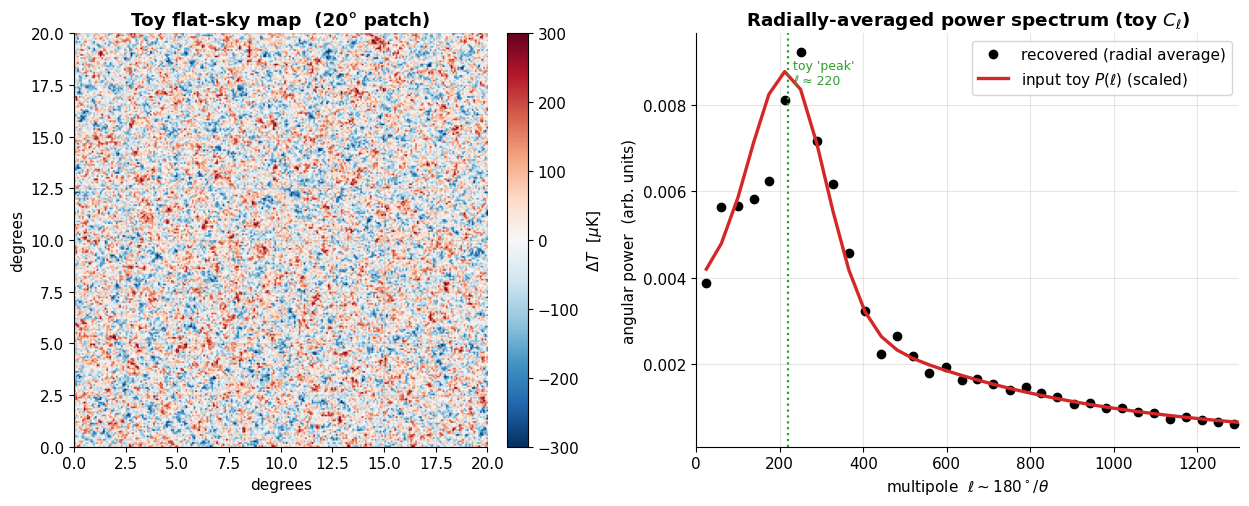

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2),
                               gridspec_kw={"width_ratios": [1, 1.1]})

# --- Left: the toy map ---
im = ax1.imshow(cmb_toy_uK, extent=[0, patch_deg, 0, patch_deg],
                cmap="RdBu_r", vmin=-3 * cmb_toy_uK.std(), vmax=3 * cmb_toy_uK.std())
ax1.set_xlabel("degrees")
ax1.set_ylabel("degrees")
ax1.set_title(f"Toy flat-sky map  ({patch_deg:.0f}° patch)")
fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, label=r"$\Delta T$  [$\mu$K]")

# --- Right: recovered vs input power spectrum ---
ax2.plot(ell_centres, cl_measured, "o", ms=6, color="k", label="recovered (radial average)")
ax2.plot(ell_centres, cl_input_scaled, lw=2.4, color="tab:red",
         label="input toy $P(\\ell)$ (scaled)")
ax2.axvline(ell_peak, color="tab:green", ls=":", lw=1.6)
ax2.text(ell_peak + 12, cl_measured.max() * 0.92, f"toy 'peak'\nℓ ≈ {ell_peak:.0f}",
         color="tab:green", fontsize=9)
ax2.set_xlabel(r"multipole  $\ell \sim 180^\circ/\theta$")
ax2.set_ylabel("angular power  (arb. units)")
ax2.set_title("Radially-averaged power spectrum (toy $C_\\ell$)")
ax2.set_xlim(0, 1300)
ax2.legend(loc="upper right")

fig.tight_layout()
plt.show()

The real angular power spectrum looks qualitatively like this — a broad rise to a first
peak — but with a *series* of acoustic peaks at $\ell \approx 220, 540, 800, \dots$ and a precise,
physically meaningful shape. WMAP (2003) and then Planck measured it to percent-level accuracy,
and fitting those peaks is how cosmologists weigh the universe: the total density (is space flat?),
the amount of ordinary versus dark matter, and the expansion rate all fall out of the peak
positions and heights. Our toy reproduces only the *idea* — a map's structure and its power
spectrum are two views of the same random field, linked by a Fourier transform.

## 5 · The real CMB on the sphere (HEALPix)

The toy above lived on a **flat patch**. The real CMB covers the whole sphere, so it is analysed
with **HEALPix** (equal-area sphere pixels) and **spherical harmonics** — the native language of
all-sky radio/microwave maps (Planck, WMAP, the Haslam 408 MHz synchrotron map, HI4PI). The
`healpy` library does the work: **`synfast`** turns an angular power spectrum $C_\ell$ into a
full-sky map, and **`anafast`** does the inverse, recovering $C_\ell$ from a map.

Here we feed `synfast` the **real Planck 2018 best-fit TT spectrum**, synthesise a CMB sky, then
run `anafast` to recover the spectrum — and overlay the actual Planck measurements. The first
**acoustic peak** at $\ell\approx220$ falls right out.

> `healpy` is an **optional** dependency (it wraps the HEALPix C++ library). Install it with
> `uv sync --extra cmb` (or `pip install 'jansky[cmb]'`); this section degrades gracefully to the
> spectrum-only plot if it is missing.

synfast -> a CMB realisation: Nside=256 (786,432 pixels), rms 108 uK


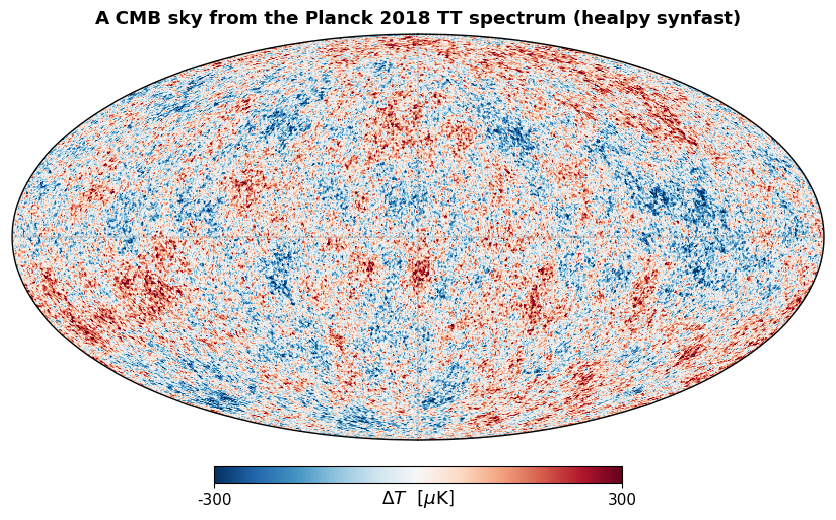

In [11]:
import numpy as np

# Planck 2018 binned TT power spectrum (D_ell = l(l+1)C_l/2pi in uK^2):
# l, measured D_ell, error, and the best-fit LCDM theory curve.
# Planck Collaboration (2020), A&A 641, A1 / A6 -- Planck Legacy Archive COM_PowerSpect_CMB-TT.
PL_ELL  = np.array([47.7, 76.5, 105.9, 135.6, 165.4, 195.3, 225.2, 255.1, 285.0, 315.0, 344.9, 374.9, 404.9, 434.8, 464.8, 494.8, 524.8, 554.8, 584.8, 614.7, 644.7, 674.7, 704.7, 734.7, 764.7, 794.7, 824.7, 854.7, 884.7, 914.7, 944.7, 974.7, 1004.6, 1034.6, 1064.6, 1094.6, 1124.6, 1154.6, 1184.6, 1214.6, 1244.6, 1274.6, 1304.6, 1334.6, 1364.6, 1394.6, 1424.6, 1454.6, 1484.6, 1514.6, 1544.6, 1574.6, 1604.6, 1634.6, 1664.6, 1694.6, 1724.6, 1754.6, 1784.6, 1814.6, 1844.6, 1874.6, 1904.6, 1934.6, 1964.6, 1994.6, 2024.6, 2054.6, 2084.6, 2114.6, 2144.6, 2174.6, 2204.6, 2234.6, 2264.6, 2294.6, 2324.6, 2354.6, 2384.6, 2414.6, 2444.6, 2474.6, 2499.0])
PL_DL   = np.array([1479.3, 2035.0, 2955.4, 3869.5, 4889.5, 5464.1, 5793.4, 5372.9, 4627.7, 3604.2, 2631.2, 2033.1, 1753.4, 1787.6, 2162.0, 2422.1, 2573.5, 2546.3, 2360.6, 2095.4, 1884.7, 1813.2, 1883.2, 2097.1, 2318.7, 2464.6, 2521.9, 2394.1, 2083.3, 1740.7, 1418.7, 1173.0, 1062.4, 1047.9, 1132.4, 1211.0, 1231.9, 1205.8, 1117.9, 968.4, 864.4, 761.6, 732.3, 737.3, 774.9, 806.6, 809.1, 777.8, 728.9, 648.3, 551.3, 476.6, 419.5, 395.2, 391.7, 392.9, 397.7, 383.0, 375.4, 340.1, 307.5, 273.9, 249.8, 244.2, 231.9, 234.7, 231.7, 219.7, 214.3, 196.7, 176.4, 152.2, 138.7, 121.5, 116.2, 117.8, 116.1, 109.7, 120.4, 90.5, 103.1, 73.7, 61.3])
PL_ERR  = np.array([50.8, 54.7, 65.0, 76.9, 86.6, 90.6, 87.1, 76.9, 62.5, 47.2, 33.9, 24.8, 20.7, 20.7, 22.8, 25.0, 25.9, 25.1, 22.7, 19.9, 17.5, 16.4, 16.8, 18.2, 19.7, 20.7, 20.5, 19.0, 16.6, 13.7, 11.1, 9.3, 8.4, 8.3, 8.7, 9.1, 9.3, 9.0, 8.3, 7.5, 6.6, 6.0, 5.7, 5.7, 5.9, 6.2, 6.3, 6.1, 5.7, 5.2, 4.7, 4.3, 4.0, 4.0, 4.0, 4.2, 4.3, 4.4, 4.5, 4.5, 4.5, 4.5, 4.6, 4.8, 5.0, 5.4, 5.9, 6.2, 6.5, 6.9, 7.2, 7.6, 8.1, 8.6, 9.3, 9.9, 10.7, 11.5, 12.4, 13.3, 14.4, 15.5, 20.9])
PL_BEST = np.array([1461.1, 2062.4, 2904.5, 3902.5, 4861.4, 5534.8, 5726.9, 5375.0, 4588.3, 3596.9, 2667.5, 2018.2, 1748.3, 1821.9, 2098.2, 2397.7, 2571.4, 2551.8, 2364.4, 2104.8, 1891.0, 1812.5, 1896.7, 2102.3, 2338.8, 2504.2, 2522.8, 2371.4, 2083.4, 1732.5, 1405.0, 1170.1, 1058.9, 1059.4, 1126.7, 1203.0, 1238.6, 1208.0, 1115.0, 986.4, 859.5, 766.8, 725.3, 731.9, 767.0, 803.6, 816.8, 792.7, 731.2, 645.0, 552.8, 473.4, 418.9, 392.2, 387.3, 393.1, 397.4, 391.4, 372.0, 341.6, 306.5, 274.2, 250.0, 236.2, 231.3, 231.2, 230.8, 226.1, 215.1, 198.3, 178.2, 158.0, 140.7, 128.0, 120.1, 115.7, 113.1, 110.3, 106.1, 100.1, 92.7, 84.8, 78.8])

NSIDE, LMAX = 256, 512
HAVE_HEALPY, cmb_map, ell_rec, dl_rec = False, None, None, None
try:
    import healpy as hp

    # Interpolate the best-fit D_ell onto every multipole, convert to C_ell, and synthesise a sky.
    ell = np.arange(LMAX + 1)
    dl_theory = np.interp(ell, PL_ELL, PL_BEST)
    cl = np.zeros(LMAX + 1)
    cl[2:] = 2.0 * np.pi * dl_theory[2:] / (ell[2:] * (ell[2:] + 1.0))  # uK^2
    np.random.seed(42)
    cmb_map = hp.synfast(cl, nside=NSIDE, lmax=LMAX, pixwin=False)  # uK
    cl_rec = hp.anafast(cmb_map, lmax=LMAX)
    ell_rec = np.arange(cl_rec.size)
    dl_rec = ell_rec * (ell_rec + 1.0) * cl_rec / (2.0 * np.pi)
    HAVE_HEALPY = True
    print(f"synfast -> a CMB realisation: Nside={NSIDE} ({cmb_map.size:,} pixels), "
          f"rms {np.std(cmb_map):.0f} uK")
    hp.mollview(cmb_map, title="A CMB sky from the Planck 2018 TT spectrum (healpy synfast)",
                unit=r"$\Delta T$  [$\mu$K]", cmap="RdBu_r", min=-300, max=300)
    hp.graticule(dpar=30, dmer=30, color="0.6", alpha=0.4)
except ImportError:
    print("healpy not installed -- install jansky[cmb] for the map + recovered spectrum.")
    print("Showing the Planck input spectrum only.")

**Figure 4** — top: a full-sky CMB realisation drawn from the Planck spectrum (the familiar
$\pm200\,\mu$K anisotropies, in a Mollweide projection). Below: the angular power spectrum — the
Planck 2018 measurements (points), the best-fit $\Lambda$CDM theory (line), and the spectrum
**recovered** from our synthetic map with `anafast`. The recovered curve scatters about the input
(that is **cosmic variance** — one sky is one realisation), but the **acoustic peaks** are
unmistakable.

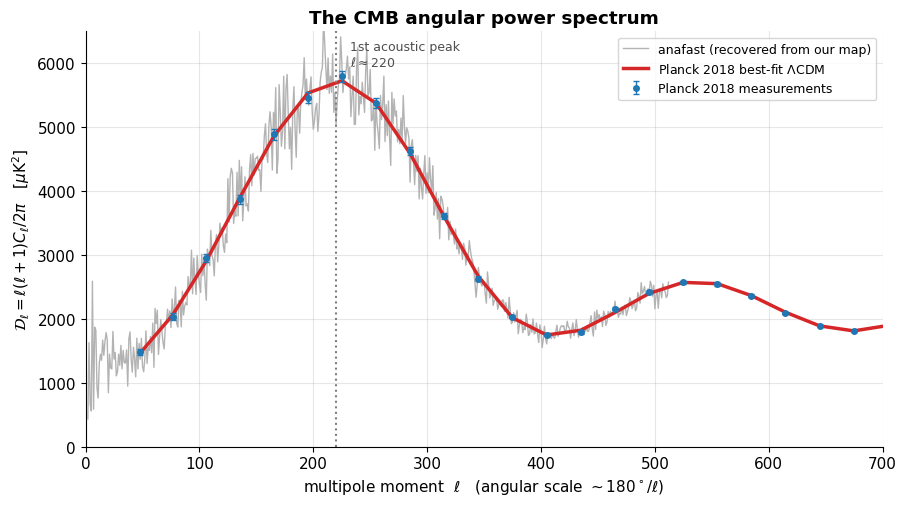

In [12]:
fig, ax = plt.subplots(figsize=(9.2, 5.2))

if HAVE_HEALPY:
    keep = (ell_rec >= 2) & (ell_rec <= 700)
    ax.plot(ell_rec[keep], dl_rec[keep], color="0.7", lw=1.0,
            label="anafast (recovered from our map)")
ax.plot(PL_ELL, PL_BEST, color="tab:red", lw=2.5, label=r"Planck 2018 best-fit $\Lambda$CDM")
ax.errorbar(PL_ELL, PL_DL, yerr=PL_ERR, fmt="o", ms=4, color="tab:blue",
            capsize=2, lw=1, label="Planck 2018 measurements")
ax.axvline(220, color="0.5", ls=":", lw=1.5)
ax.text(232, 5950, "1st acoustic peak\n" + r"$\ell\approx220$", fontsize=9, color="0.3")
ax.set_xlim(0, 700)
ax.set_ylim(0, 6500)
ax.set_xlabel(r"multipole moment  $\ell$   (angular scale $\sim 180^\circ/\ell$)")
ax.set_ylabel(r"$\mathcal{D}_\ell = \ell(\ell+1)C_\ell/2\pi$   [$\mu$K$^2$]")
ax.set_title("The CMB angular power spectrum")
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()
plt.show()

## Try it yourself

1. **Watch the peak move (Wien's law).** Re-run the §2 blackbody cell with a different
   temperature — try $T = 10\,\mathrm{K}$, $T = 100\,\mathrm{K}$, and the hot early universe at
   recombination, $T \approx 3000\,\mathrm{K}$. Confirm that the Planck peak frequency scales
   *linearly* with $T$ (that is Wien's displacement law, $\nu_\mathrm{peak} \propto T$). At
   $3000\,\mathrm{K}$ the peak is in the near-infrared/visible — which is why the universe was
   *glowing* at recombination, and why the CMB we see today (redshifted by $z \approx 1100$) has
   cooled to microwaves.

2. **Change the dipole speed.** In §3, replace `v_sun` with a different velocity and recompute
   the dipole amplitude. What speed would give a $1\,\mathrm{mK}$ dipole? A $10\,\mathrm{mK}$ one?
   Since $\Delta T = T_0\,v/c$ is linear in $v$, you should be able to predict the answer before
   you run it — then check.

3. **Reshape the toy power spectrum.** In §4, edit `toy_power_spectrum`: move `ell_peak` to a
   larger value (smaller angular scales) and watch the blobs in the map shrink. Or add a *second*
   Gaussian bump (a second "acoustic peak") and confirm both show up in the radially-averaged
   spectrum. Try widening `ell_width` and see the map's features lose their characteristic size.
   This is the map↔spectrum correspondence at the heart of CMB analysis.

<details>
<summary>Solution</summary>

### 1 · Watch the peak move (Wien's law)

The peak of $B_\nu$ sits at $h\nu_\mathrm{peak} \approx 2.821\,k_B T$, so

$$
\nu_\mathrm{peak} \;\approx\; 2.821\,\frac{k_B T}{h}
\;=\; (58.79\ \mathrm{GHz\,K^{-1}})\times T ,
$$

which is **linear in $T$** — that is Wien's displacement law, $\nu_\mathrm{peak}\propto T$. Reusing the §2 idiom (the analytic `nu_peak_wien` together with `units.planck_brightness` to confirm the grid maximum):

```python
coef = 2.8214393721 * const.k_B / const.h          # the 2.821 k_B/h prefactor
for T in [2.725, 10.0, 100.0, 3000.0] * u.K:
    nu_wien = (coef * T).to(u.GHz)
    # confirm numerically against the exact Planck curve
    freq = np.logspace(8, np.log10(coef.to_value('Hz/K') * T.value * 5), 4000) * u.Hz
    B = units.planck_brightness(T, freq)
    nu_grid = freq[int(np.argmax(B.value))].to(u.GHz)
    lam = (const.c / nu_wien).to(u.um)
    print(f"T={T.value:>7} K   nu_peak={nu_wien:8.4g}   (grid {nu_grid:8.4g})   "
          f"lambda={lam:8.4g}   nu/T={(nu_wien/T).to('GHz/K'):.4g}")
```

| $T$ | $\nu_\mathrm{peak}$ (analytic) | grid check | $\lambda_\mathrm{peak}$ | $\nu_\mathrm{peak}/T$ |
|---|---|---|---|---|
| $2.725\,\mathrm{K}$ | $160.2\,\mathrm{GHz}$ | $160.2\,\mathrm{GHz}$ | $1871\,\mu\mathrm{m}$ | $58.79\,\mathrm{GHz\,K^{-1}}$ |
| $10\,\mathrm{K}$ | $587.9\,\mathrm{GHz}$ | $587.2\,\mathrm{GHz}$ | $510\,\mu\mathrm{m}$ | $58.79\,\mathrm{GHz\,K^{-1}}$ |
| $100\,\mathrm{K}$ | $5879\,\mathrm{GHz}$ | $5882\,\mathrm{GHz}$ | $51\,\mu\mathrm{m}$ | $58.79\,\mathrm{GHz\,K^{-1}}$ |
| $3000\,\mathrm{K}$ | $1.764\times10^{5}\,\mathrm{GHz}$ | $1.767\times10^{5}\,\mathrm{GHz}$ | $1.7\,\mu\mathrm{m}$ | $58.79\,\mathrm{GHz\,K^{-1}}$ |

The ratio $\nu_\mathrm{peak}/T$ is constant to all four figures — exactly the statement $\nu_\mathrm{peak}\propto T$. The peak shifts by a factor of $10$ in frequency for every factor of $10$ in temperature: $\times 3.67$ from $2.725\,\mathrm{K}$ to $10\,\mathrm{K}$, and so on up to $3000\,\mathrm{K}$, where $\lambda_\mathrm{peak}\approx 1.7\,\mu\mathrm{m}$ sits in the **near-infrared, with the hot tail spilling into the visible** — the universe at recombination was literally *glowing*. Redshifting by $z\approx 1100$ ($\nu \to \nu/(1+z)$, equivalently $T \to T/(1+z)$) cools that $3000\,\mathrm{K}$ glow to today's $2.725\,\mathrm{K}$ microwave background: $3000/1101 \approx 2.7\,\mathrm{K}$.

### 2 · Change the dipole speed

The dipole amplitude is linear in $v$, $\Delta T = T_0\,v/c$, so it simply inverts:

$$
v \;=\; \frac{\Delta T}{T_0}\,c .
$$

Reusing the §3 idiom (`v_sun`, `beta = v/c`, `dT_dipole = T_cmb * beta`):

```python
for dT in [1.0, 10.0] * u.mK:
    v = (dT / T_cmb * const.c).to(u.km / u.s)        # invert Delta T = T0 * v/c
    print(f"Delta T = {dT:>5}  ->  v = {v:.4g}")
```

- A **$1\,\mathrm{mK}$** dipole needs $v = (1\,\mathrm{mK}/2.725\,\mathrm{K})\,c \approx \mathbf{110\ km\,s^{-1}}$.
- A **$10\,\mathrm{mK}$** dipole needs $v \approx \mathbf{1100\ km\,s^{-1}}$ — ten times larger, because of the linearity.

As a sanity check, the actual $v_\mathrm{sun} = 369.82\,\mathrm{km\,s^{-1}}$ gives $\Delta T = 3.3615\,\mathrm{mK}$, matching the measured $3.3621 \pm 0.0010\,\mathrm{mK}$. You can read the two answers straight off this number without re-running: $369.82 / 3.3615 \approx 110\,\mathrm{km\,s^{-1}\,mK^{-1}}$, so $1\,\mathrm{mK}\to 110\,\mathrm{km\,s^{-1}}$ and $10\,\mathrm{mK}\to 1100\,\mathrm{km\,s^{-1}}$.

### 3 · Reshape the toy power spectrum

`toy_power_spectrum` is just an envelope plus a Gaussian bump, so editing `ell_peak`, `ell_width`, or adding a second bump directly changes both the recovered spectrum **and** the look of the map. The map↔spectrum link is the Fourier relation $\theta \sim 180^\circ/\ell$: pushing the bump to higher $\ell$ moves power to smaller angular scales, so **the blobs shrink**.

**Move the peak to smaller scales.** Set `ell_peak = 600` (keep the rest of §4 unchanged) and re-run the generate/measure cells with the same `rng(seed=2725)`:

```python
ell_peak = 600.0          # was 220
# ... regenerate cmb_toy and re-bin exactly as in section 4 ...
# recovered peak lands near ell = 597  (input bump at 600)
```

The recovered radial spectrum now peaks at $\ell \approx 597$, and the characteristic blob size drops from $\sim 180^\circ/220 \approx 0.8^\circ$ to $\sim 180^\circ/600 \approx 0.3^\circ$ — visibly finer structure in the map.

**Add a second "acoustic peak".** Drop a second Gaussian into the function:

```python
def toy_power_spectrum(ell):
    ell = np.asarray(ell, dtype=float)
    envelope = 1.0 / (1.0 + (ell / 600.0) ** 2)
    bump1 = 1.5 * np.exp(-0.5 * ((ell - 220.0) / 90.0) ** 2)   # first 'peak'
    bump2 = 1.2 * np.exp(-0.5 * ((ell - 700.0) /  70.0) ** 2)  # second 'peak'
    return envelope + bump1 + bump2
```

Regenerating and radially averaging recovers **both** features — local maxima appear near $\ell \approx 250$ and $\ell \approx 710$ in the binned spectrum (the low one shifted up a little by the falling envelope underneath it), the toy analogue of the real $C_\ell$'s harmonic series of acoustic peaks at $\ell \approx 220, 540, 800,\dots$

**Widen the bump.** Increasing `ell_width` (say $90 \to 250$) spreads the power across a *range* of scales, so the map's blobs lose any single characteristic size and the field looks more like featureless noise — there is no longer one dominant ripple wavelength. This is exactly why a *sharp* acoustic peak in the real spectrum corresponds to a well-defined preferred spot size on the CMB sky: a narrow peak in $\ell$ means a sharply preferred scale in $\theta$.

</details>

## Recap

- The CMB was discovered as a piece of **radio astronomy**: Penzias & Wilson's isotropic
  $\sim 3.5\,\mathrm{K}$ **excess antenna temperature** at $4080\,\mathrm{MHz}$ (1965), explained
  the same year by Dicke et al. as relic radiation from a hot Big Bang.
- It is a near-perfect **$2.725\,\mathrm{K}$ blackbody** (COBE/FIRAS, 1994). Using
  `units.planck_brightness` we found its $\sim 160\,\mathrm{GHz}$ microwave peak, and with
  `units.rayleigh_jeans_brightness` and `units.flux_to_brightness_temperature` we showed that
  radio observations sit on the **Rayleigh–Jeans tail** of Chapter 2, where the brightness
  temperature is flat and equal to $T_0$ — exactly why an antenna temperature was the natural
  thing to report.
- Our motion through the radiation imprints a **kinematic dipole**, $\Delta T/T = (v/c)\cos\theta$,
  with amplitude $T_0\,v/c \approx 3.36\,\mathrm{mK}$ for $v \approx 370\,\mathrm{km\,s^{-1}}$.
- The residual $\sim 10\,\mu\mathrm{K}$ **anisotropy** is summarised by the **angular power
  spectrum** $C_\ell$. Our flat-sky FFT **toy** showed the map↔spectrum relationship; the real
  $C_\ell$, with its acoustic peaks, was measured by COBE, WMAP, and Planck and underpins modern
  precision cosmology.

The thread back to Chapter 2 is direct: the brightness-temperature reasoning that makes radio
astronomy tick is *the same physics* that let a $3.5\,\mathrm{K}$ noise floor become the founding
measurement of cosmology — a radio measurement that earned two Nobel Prizes (1978 and 2006).

## What's next

You have now seen the radio sky from the nearest interference to the edge of the observable
universe. The CMB is the oldest light there is; everything else in this course — the synchrotron
sources, the HI, the pulsars, the FRBs — sits between us and it. For the full year-by-year arc of
how the field got here, see the [landmark papers timeline](../docs/papers-timeline.md), and for
any unfamiliar term, the [glossary](../docs/glossary.md).